In [7]:
F = 1500  
V = 1000  
alpha = 0.5
C = 2


D = F / V

mu = ((1 + alpha) - alpha * C) * D

print("Dilution rate D =", D, "h^-1")
print("Specific growth rate mu =", mu, "h^-1")

Dilution rate D = 1.5 h^-1
Specific growth rate mu = 0.75 h^-1


In [2]:

mu = 0.75    
mu_m = 1.0  
K_s = 0.01     

S = (mu * K_s) / (mu_m - mu)

print("Substrate concentration S =", S, "g/L")

Substrate concentration S = 0.03 g/L


In [3]:
Yxs = 0.5     
D = 1.5       
S0 = 2.0      
S = 0.03     
mu = 0.75     
C = 2.0

X = (Yxs * D * (S0 - S)) / mu

X1 = C * X

print("Cell concentration in reactor X =", X, "g/L")
print("Cell concentration in recycle stream X1 =", X1, "g/L")

Cell concentration in reactor X = 1.97 g/L
Cell concentration in recycle stream X1 = 3.94 g/L


In [5]:
alpha = 0.5
X = 1.97     
X1 = 3.94

X2 = (1 + alpha) * X - alpha * X1

print("Cell concentration in separator effluent X2 =", X2, "g/L")

Cell concentration in separator effluent X2 = 0.9850000000000001 g/L


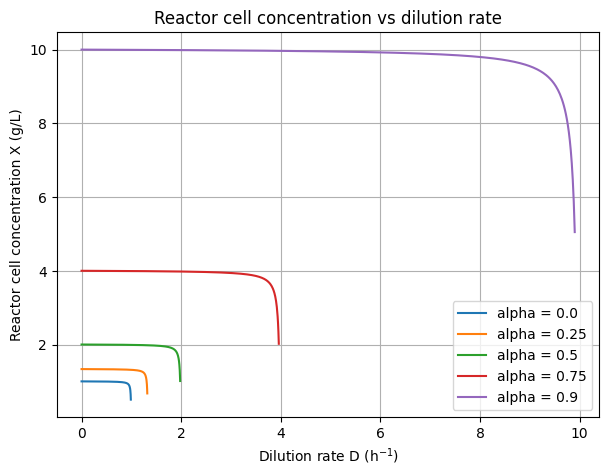

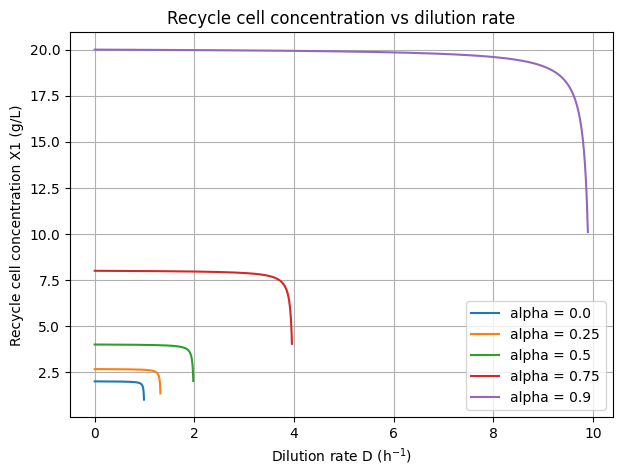

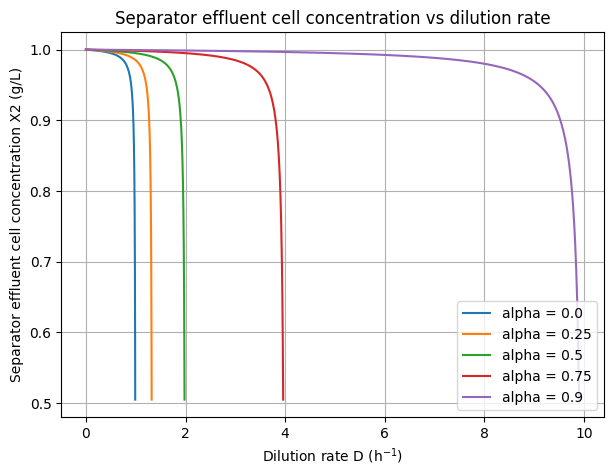

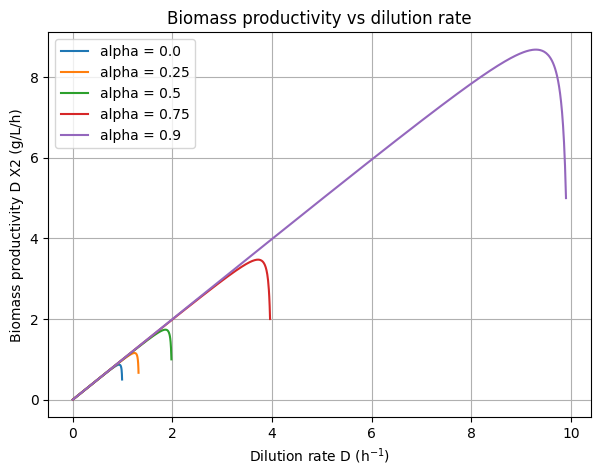

alpha = 0.00, Dmax = 1.000 h^-1
alpha = 0.25, Dmax = 1.333 h^-1
alpha = 0.50, Dmax = 2.000 h^-1
alpha = 0.75, Dmax = 4.000 h^-1
alpha = 0.90, Dmax = 10.000 h^-1


In [6]:
import numpy as np
import matplotlib.pyplot as plt


Yxs = 0.5     
S0 = 2.0     
mu_m = 1.0     
Ks = 0.01      
C = 2.0         

alpha_values = [0.0, 0.25, 0.5, 0.75, 0.9]

results = {}

for alpha in alpha_values:
    k = (1 + alpha) - alpha * C
    
    Dmax = mu_m / k
    
    D = np.linspace(0.001, 0.99 * Dmax, 500)
    
    mu = k * D
    
    S = (mu * Ks) / (mu_m - mu)
    
    X = (Yxs * D * (S0 - S)) / mu
    
    X1 = C * X
   
    X2 = k * X
    
    productivity = D * X2
    
    results[alpha] = {
        "D": D,
        "Dmax": Dmax,
        "X": X,
        "X1": X1,
        "X2": X2,
        "productivity": productivity
    }

# Plot reactor cell concentration X
plt.figure(figsize=(7, 5))
for alpha in alpha_values:
    plt.plot(results[alpha]["D"], results[alpha]["X"], label=f"alpha = {alpha}")
plt.xlabel("Dilution rate D (h$^{-1}$)")
plt.ylabel("Reactor cell concentration X (g/L)")
plt.title("Reactor cell concentration vs dilution rate")
plt.legend()
plt.grid(True)
plt.show()

# Plot recycle cell concentration X1
plt.figure(figsize=(7, 5))
for alpha in alpha_values:
    plt.plot(results[alpha]["D"], results[alpha]["X1"], label=f"alpha = {alpha}")
plt.xlabel("Dilution rate D (h$^{-1}$)")
plt.ylabel("Recycle cell concentration X1 (g/L)")
plt.title("Recycle cell concentration vs dilution rate")
plt.legend()
plt.grid(True)
plt.show()

# Plot separator effluent cell concentration X2
plt.figure(figsize=(7, 5))
for alpha in alpha_values:
    plt.plot(results[alpha]["D"], results[alpha]["X2"], label=f"alpha = {alpha}")
plt.xlabel("Dilution rate D (h$^{-1}$)")
plt.ylabel("Separator effluent cell concentration X2 (g/L)")
plt.title("Separator effluent cell concentration vs dilution rate")
plt.legend()
plt.grid(True)
plt.show()

# Plot biomass productivity
plt.figure(figsize=(7, 5))
for alpha in alpha_values:
    plt.plot(results[alpha]["D"], results[alpha]["productivity"], label=f"alpha = {alpha}")
plt.xlabel("Dilution rate D (h$^{-1}$)")
plt.ylabel("Biomass productivity D X2 (g/L/h)")
plt.title("Biomass productivity vs dilution rate")
plt.legend()
plt.grid(True)
plt.show()

# Print Dmax values
for alpha in alpha_values:
    print(f"alpha = {alpha:.2f}, Dmax = {results[alpha]['Dmax']:.3f} h^-1")